In [2]:
# PTB-XL xResnet1D Model
import os
import ast
import wfdb
import torch
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc

In [3]:
# Dataset and Preprocessing
from scipy import signal
dataset_path = Path("/users/PLS0150/shreeshtee/PTBXL-Dataset-Thesiswork/physionet.org/files/ptb-xl/1.0.3")
ptbxl_path = dataset_path / "ptbxl_database.csv"
waveform_path = dataset_path

df = pd.read_csv(ptbxl_path)
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
df['scp_keys'] = df['scp_codes'].apply(lambda x: list(x.keys()))
target_labels = ['NORM', 'AFIB', 'PVC', 'LVH', 'IMI', 'ASMI', 'LAFB', 'IRBBB']
df['scp_filtered'] = df['scp_keys'].apply(lambda x: [k for k in x if k in target_labels])
df = df[df['scp_filtered'].map(len) > 0]
mlb = MultiLabelBinarizer(classes=target_labels)
y = mlb.fit_transform(df['scp_filtered'])
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)

def load_ecg(record_path):
    record = wfdb.rdrecord(record_path)
    return record.p_signal

class PTBXL_Dataset(Dataset):
    def __init__(self, df, labels, base_dir):
        self.df = df
        self.labels = labels
        self.base_dir = base_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        full_path = os.path.join(self.base_dir, row['filename_lr'])
        signal = load_ecg(full_path).T
        return torch.tensor(signal, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.float32)

train_dataset = PTBXL_Dataset(X_train, y_train, waveform_path)
test_dataset = PTBXL_Dataset(X_test, y_test, waveform_path)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=8, num_workers=2, pin_memory=True)
val_loader = DataLoader(test_dataset, batch_size=8, num_workers=2, pin_memory=True)

In [4]:
# XResNet1D Model Definition
class ConvLayer(nn.Sequential):
    def __init__(self, ni, nf, ks=3, stride=1, padding=None, bias=None, act_cls=nn.ReLU):
        if padding is None: padding = (ks - 1) // 2
        conv = nn.Conv1d(ni, nf, kernel_size=ks, stride=stride, padding=padding, bias=bias or False)
        bn = nn.BatchNorm1d(nf)
        layers = [conv, bn]
        if act_cls is not None:
            layers.append(act_cls())
        super().__init__(*layers)

class ResBlock(nn.Module):
    def __init__(self, ni, nf, stride=1):
        super().__init__()
        self.convs = nn.Sequential(
            ConvLayer(ni, nf, stride=stride),
            ConvLayer(nf, nf, act_cls=None)
        )
        self.idconv = nn.Identity() if ni == nf and stride == 1 else ConvLayer(ni, nf, ks=1, stride=stride, act_cls=None)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.convs(x) + self.idconv(x))

class XResNet1d(nn.Sequential):
    def __init__(self, layers, input_channels=12, num_classes=10):
        self.block_sizes = [64, 128, 256, 512]
        stem = [ConvLayer(input_channels, 64, ks=7, stride=2), nn.MaxPool1d(kernel_size=3, stride=2, padding=1)]
        blocks = []
        ni = 64
        for i, n_blocks in enumerate(layers):
            nf = self.block_sizes[i]
            for j in range(n_blocks):
                stride = 2 if j == 0 and i != 0 else 1
                blocks.append(ResBlock(ni, nf, stride=stride))
                ni = nf
        head = [nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(ni, num_classes)]
        super().__init__(*stem, *blocks, *head)

In [5]:
# Training loop with Weights & Biases logging
import wandb

wandb.init(
    project="Hybrid-CNN-Transformer-ECG-notebooks_individual_notebooks",
    name="xResNet"
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: sdhakal13 (sdhakal13-youngstown-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [6]:
import numpy as np
from sklearn.metrics import roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = XResNet1d(
    [2, 2, 2, 2],
    input_channels=12,
    num_classes=len(target_labels)
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100

for epoch in range(epochs):

    # ================= TRAIN =================
    model.train()
    total_loss, correct, total = 0, 0, 0

    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for signals, labels in train_loader_tqdm:
        signals, labels = signals.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        #  loss (sample-wise)
        total_loss += loss.item() * signals.size(0)

        # Accuracy
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.numel()

        train_loader_tqdm.set_postfix(loss=loss.item())

    train_loss = total_loss / len(train_loader.dataset)
    train_acc = correct / total

    # ================= VALIDATION =================
    model.eval()
    val_preds, val_labels_list = [], []
    val_loss = 0.0

    with torch.no_grad():
        for signals, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            signals, labels = signals.to(device), labels.to(device)

            outputs = model(signals)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * signals.size(0)

            val_preds.append(torch.sigmoid(outputs).cpu().numpy())
            val_labels_list.append(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)

    val_preds = np.vstack(val_preds)
    val_labels = np.vstack(val_labels_list)

    try:
        val_auc = roc_auc_score(val_labels, val_preds, average='macro')
    except Exception as e:
        val_auc = 0.0
        print("AUC error:", e)

    # ================= LOG =================
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_auc": val_auc})

    # ================= PRINT =================
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

Epoch 1/100 [Val]: 100%|██████████| 447/447 [00:06<00:00, 68.60it/s]


Epoch 1 | Train Loss: 0.2532 | Train Acc: 0.9017 | Val Loss: 0.2534 | Val AUC: 0.9225


Epoch 2/100 [Val]: 100%|██████████| 447/447 [00:05<00:00, 74.57it/s]


Epoch 2 | Train Loss: 0.1865 | Train Acc: 0.9258 | Val Loss: 0.2371 | Val AUC: 0.9438


Epoch 3/100 [Val]: 100%|██████████| 447/447 [00:05<00:00, 75.28it/s]


...

Epoch 98 | Train Loss: 0.0042 | Train Acc: 0.9987 | Val Loss: 0.4492 | Val AUC: 0.9545


Epoch 99/100 [Val]: 100%|██████████| 447/447 [00:05<00:00, 80.28it/s]


Epoch 99 | Train Loss: 0.0040 | Train Acc: 0.9989 | Val Loss: 0.4181 | Val AUC: 0.9576


Epoch 100/100 [Val]: 100%|██████████| 447/447 [00:05<00:00, 80.23it/s]


Epoch 100 | Train Loss: 0.0038 | Train Acc: 0.9987 | Val Loss: 0.4493 | Val AUC: 0.9528


In [7]:
# Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for signals, labels in test_loader:
        signals, labels = signals.to(device), labels.to(device)
        outputs = model(signals)
        y_true.append(labels.cpu().numpy())
        y_pred.append(torch.sigmoid(outputs).cpu().numpy())

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

print("Classification Report:")
print(classification_report(y_true > 0.5, y_pred > 0.5, target_names=mlb.classes_))
print("Macro ROC-AUC:", roc_auc_score(y_true, y_pred, average='macro'))

Classification Report:
              precision    recall  f1-score   support

        NORM       0.87      0.89      0.88      1878
        AFIB       0.86      0.94      0.90       298
         PVC       0.90      0.79      0.84       257
         LVH       0.57      0.70      0.63       409
         IMI       0.73      0.63      0.67       558
        ASMI       0.81      0.60      0.69       458
        LAFB       0.81      0.78      0.79       345
       IRBBB       0.69      0.56      0.62       233

   micro avg       0.80      0.78      0.79      4436
   macro avg       0.78      0.74      0.75      4436
weighted avg       0.81      0.78      0.79      4436
 samples avg       0.80      0.80      0.79      4436

Macro ROC-AUC: 0.9527548435535864


/users/PLS0150/shreeshtee/.conda/envs/acorn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
# COLLECT XRESNET PREDICTIONS
model.eval()
y_true_xresnet = []
y_pred_xresnet = []

with torch.no_grad():
    for signals, labels in tqdm(test_loader, desc='Evaluating XResNet'):
        signals = signals.to(device)
        outputs = model(signals)
        y_pred_xresnet.append(torch.sigmoid(outputs).cpu().numpy())
        y_true_xresnet.append(labels.numpy())

y_true_xresnet = np.vstack(y_true_xresnet)
y_pred_xresnet = np.vstack(y_pred_xresnet)

print(f"Collected {len(y_true_xresnet)} test samples")

Evaluating XResNet: 100%|██████████| 447/447 [00:05<00:00, 77.34it/s]

Collected 3576 test samples


In [9]:
# Helper function to compute macro-average ROC
def compute_macro_roc(y_true, y_pred):
    from sklearn.metrics import roc_curve, auc
    import numpy as np

    n_classes = y_true.shape[1]
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}

    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    return all_fpr, mean_tpr, macro_auc

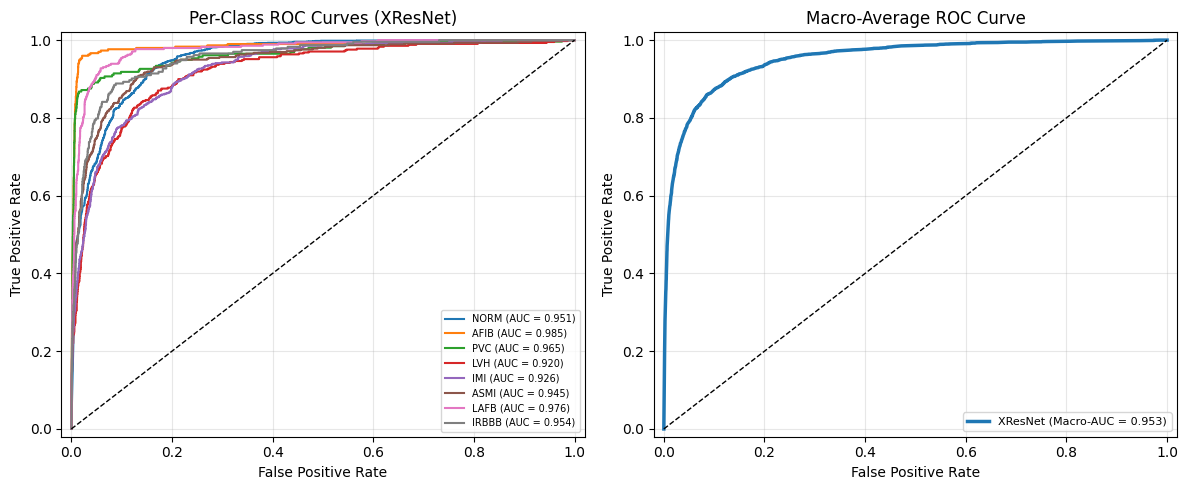

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Use XResNet predictions
y_true = np.array(y_true_xresnet)
y_pred = np.array(y_pred_xresnet)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LEFT: Per-class ROC

fpr_dict = {}
tpr_dict = {}

for i, label in enumerate(target_labels):
    if len(np.unique(y_true[:, i])) < 2:
        continue

    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    fpr_dict[i] = fpr
    tpr_dict[i] = tpr

    axes[0].plot(fpr, tpr, lw=1.5, label=f'{label} (AUC = {roc_auc:.3f})')

# Diagonal
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)

axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])
axes[0].set_title('Per-Class ROC Curves (XResNet)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

# RIGHT: Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in fpr_dict]))

mean_tpr = np.zeros_like(all_fpr)

for i in fpr_dict:
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])

mean_tpr /= len(fpr_dict)

macro_auc = auc(all_fpr, mean_tpr)

axes[1].plot(all_fpr, mean_tpr,
             lw=2.5,
             label=f'XResNet (Macro-AUC = {macro_auc:.3f})')

# Diagonal
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)

axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.02])
axes[1].set_title('Macro-Average ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Layout + Save
plt.tight_layout()
plt.savefig('xresnet_roc_model.png', dpi=300, bbox_inches='tight')
plt.show()